# EmbeddingMLP — Truncagem a 150 chars

Testa o **EmbeddingMLP** (embeddings treináveis + mean-pool + MLP) com textos truncados
a **150 caracteres**, simulando o regime do dataset externo (~100-120 chars).



| Parâmetro | Valor |
|---|---|
| `TRUNCATE_CHARS` | **150** (mudar para `None` para desligar) |
| `MAX_LEN` | 30 tokens (≈ 150 chars) |
| Optimizador | Optuna (10 trials) |

In [1]:
import re, time, warnings
from collections import Counter
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score as sk_f1
import matplotlib.pyplot as plt
from datasets import load_dataset
import optuna

warnings.filterwarnings('ignore')

# ── CONFIG ────────────────────────────────────────────────────────────────────
SEED           = 808815
TRUNCATE_CHARS = 150    # None = sem truncagem | 150 = simula dataset externo
MAX_WORDS_RNN  = 10_000
MAX_LEN        = 30     # ~150 chars ≈ 20-30 tokens; era 180 sem truncagem
BATCH_SIZE     = 128
EPOCHS         = 20
LR             = 1e-3
PATIENCE       = 5

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

print(f'Device: {DEVICE}')
print(f'TRUNCATE_CHARS={TRUNCATE_CHARS}  MAX_LEN={MAX_LEN}')

Device: cuda
TRUNCATE_CHARS=150  MAX_LEN=30


## 1. Dados e Pré-processamento

In [2]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text, flags=re.UNICODE)
    return re.sub(r'\s+', ' ', text).strip()

df = load_dataset('BrunoFilipeRDS/dataset_2500_bal', split='train').to_pandas()
df = df.dropna(subset=['text', 'label']).copy()
df['text']  = df['text'].astype(str).apply(clean_text)
df['label'] = df['label'].astype(str)

# ── Truncagem opcional ────────────────────────────────────────────────────────
if TRUNCATE_CHARS is not None:
    before = df['text'].str.len().mean()
    df['text'] = df['text'].str[:TRUNCATE_CHARS]
    after  = df['text'].str.len().mean()
    print(f'Textos truncados a {TRUNCATE_CHARS} chars  '
          f'(comprimento médio: {before:.0f} → {after:.0f} chars)')
else:
    print(f'Sem truncagem — comprimento médio: {df["text"].str.len().mean():.0f} chars')

CLASSES      = sorted(df['label'].unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
N_CLASSES    = len(CLASSES)
df['label_id'] = df['label'].map(CLASS_TO_IDX)

texts  = df['text'].tolist()
labels = df['label_id'].tolist()

print(f'Dataset: {len(df)} linhas | {N_CLASSES} classes: {CLASSES}')

# Split estratificado 70/15/15
X_tv, X_test, y_tv, y_test = train_test_split(
    texts, labels, test_size=0.15, stratify=labels, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=round(0.15/0.85, 4), stratify=y_tv, random_state=SEED)

print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Textos truncados a 150 chars  (comprimento médio: 1326 → 150 chars)
Dataset: 12500 linhas | 5 classes: ['anthropic', 'google', 'human', 'meta', 'openai']
Train: 8749  |  Val: 1876  |  Test: 1875


## 2. Vocabulário e SequenceDataset

In [3]:
def build_vocab(texts, max_words=10_000):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for i, (w, _) in enumerate(counter.most_common(max_words - 2), start=2):
        vocab[w] = i
    return vocab

vocab_rnn     = build_vocab(X_train, max_words=MAX_WORDS_RNN)
VOCAB_SIZE_RNN = len(vocab_rnn)
print(f'Vocab RNN: {VOCAB_SIZE_RNN} tokens')

class SequenceDataset(Dataset):
    def __init__(self, texts, labels, word_index, max_len):
        self.texts      = texts
        self.labels     = torch.tensor(labels, dtype=torch.long)
        self.word_index = word_index
        self.max_len    = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        toks = self.texts[idx].split()
        seq  = [self.word_index.get(t, 1) for t in toks][:self.max_len]
        seq += [0] * (self.max_len - len(seq))
        return torch.tensor(seq, dtype=torch.long), self.labels[idx]

seq_train_loader = DataLoader(SequenceDataset(X_train, y_train, vocab_rnn, MAX_LEN),
                              BATCH_SIZE, shuffle=True, drop_last=True)
seq_val_loader   = DataLoader(SequenceDataset(X_val,   y_val,   vocab_rnn, MAX_LEN), BATCH_SIZE)
seq_test_loader  = DataLoader(SequenceDataset(X_test,  y_test,  vocab_rnn, MAX_LEN), BATCH_SIZE)
print('DataLoaders prontos.')

Vocab RNN: 10000 tokens
DataLoaders prontos.


## 3. Modelo EmbeddingMLP e infraestrutura de treino

In [4]:
class EmbeddingMLP(nn.Module):
    """
    Embedding(vocab, E) → masked mean-pool → Linear(E,H) → BN → ReLU → Dropout
                        → Linear(H, H//2)  → BN → ReLU → Dropout → Linear(H//2, C)
    Sem recorrência — embeddings treináveis end-to-end.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x):                       # x: (B, T)
        mask   = (x != 0).float().unsqueeze(-1) # (B, T, 1)
        emb    = self.embedding(x)              # (B, T, E)
        pooled = (emb * mask).sum(1) / mask.sum(1).clamp(min=1)  # (B, E)
        return self.net(pooled)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out  = model(x)
            total_loss += criterion(out, y).item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total


def get_preds(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            preds.extend(model(x.to(DEVICE)).argmax(1).cpu().tolist())
            targets.extend(y.tolist())
    return preds, targets


def train_model(model, train_loader, val_loader,
                epochs=EPOCHS, lr=LR, patience=PATIENCE):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2)

    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val  = float('inf')
    best_state, no_improve = None, 0

    for ep in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        tr_l, tr_a = evaluate(model, train_loader, criterion)
        vl_l, vl_a = evaluate(model, val_loader,   criterion)
        for k, v in zip(['train_loss','val_loss','train_acc','val_acc'],
                        [tr_l, vl_l, tr_a, vl_a]):
            history[k].append(v)

        scheduler.step(vl_l)
        print(f'Época {ep:3d}/{epochs}  loss={tr_l:.4f}  acc={tr_a:.4f}  '
              f'val_loss={vl_l:.4f}  val_acc={vl_a:.4f}  '
              f'lr={optimizer.param_groups[0]["lr"]:.2e}')

        if vl_l < best_val:
            best_val   = vl_l
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  ↳ Early stopping época {ep}. Melhor val_loss={best_val:.4f}')
                break

    if best_state:
        model.load_state_dict(best_state)
        model.to(DEVICE)
    return history


print('EmbeddingMLP e infraestrutura prontos.')

EmbeddingMLP e infraestrutura prontos.


## 4. Optuna — Optimização de Hiperparâmetros

In [5]:
print('=' * 60)
print('Optuna Study: EmbeddingMLP')
print('=' * 60)

def objective(trial):
    lr         = trial.suggest_float('lr',        1e-4, 1e-2, log=True)
    dropout    = trial.suggest_float('dropout',   0.1,  0.5)
    embed_dim  = trial.suggest_categorical('embed_dim',  [64, 128, 256])
    hidden_dim = trial.suggest_categorical('hidden_dim', [128, 256, 512])

    model = EmbeddingMLP(VOCAB_SIZE_RNN, embed_dim, hidden_dim, N_CLASSES, dropout)
    try:
        history = train_model(model, seq_train_loader, seq_val_loader,
                              epochs=10, lr=lr, patience=3)
        return min(history['val_loss'])
    except Exception:
        return float('inf')

study = optuna.create_study(direction='minimize', study_name='EmbeddingMLP-truncated')
study.optimize(objective, n_trials=10)
print('Melhores hiperparâmetros:', study.best_params)

[I 2026-03-16 18:33:24,384] A new study created in memory with name: EmbeddingMLP-truncated


Optuna Study: EmbeddingMLP
Época   1/10  loss=1.4682  acc=0.3935  val_loss=1.4883  val_acc=0.3566  lr=3.01e-04
Época   2/10  loss=1.3634  acc=0.4637  val_loss=1.3913  val_acc=0.4312  lr=3.01e-04
Época   3/10  loss=1.2767  acc=0.5002  val_loss=1.3122  val_acc=0.4622  lr=3.01e-04
Época   4/10  loss=1.2064  acc=0.5254  val_loss=1.2451  val_acc=0.4909  lr=3.01e-04
Época   5/10  loss=1.1423  acc=0.5511  val_loss=1.1812  val_acc=0.5171  lr=3.01e-04
Época   6/10  loss=1.0858  acc=0.5733  val_loss=1.1334  val_acc=0.5277  lr=3.01e-04
Época   7/10  loss=1.0364  acc=0.5915  val_loss=1.0885  val_acc=0.5458  lr=3.01e-04
Época   8/10  loss=0.9913  acc=0.6093  val_loss=1.0525  val_acc=0.5576  lr=3.01e-04
Época   9/10  loss=0.9511  acc=0.6272  val_loss=1.0232  val_acc=0.5698  lr=3.01e-04


[I 2026-03-16 18:33:36,472] Trial 0 finished with value: 0.9921127915382385 and parameters: {'lr': 0.0003007319505704109, 'dropout': 0.43349602432488976, 'embed_dim': 64, 'hidden_dim': 256}. Best is trial 0 with value: 0.9921127915382385.


Época  10/10  loss=0.9116  acc=0.6410  val_loss=0.9921  val_acc=0.5730  lr=3.01e-04
Época   1/10  loss=0.8317  acc=0.6685  val_loss=0.9408  val_acc=0.6077  lr=2.08e-03
Época   2/10  loss=0.5924  acc=0.7734  val_loss=0.8005  val_acc=0.6626  lr=2.08e-03
Época   3/10  loss=0.4507  acc=0.8331  val_loss=0.7752  val_acc=0.6594  lr=2.08e-03
Época   4/10  loss=0.3355  acc=0.8804  val_loss=0.7851  val_acc=0.6812  lr=2.08e-03
Época   5/10  loss=0.2328  acc=0.9162  val_loss=0.8345  val_acc=0.6924  lr=2.08e-03


[I 2026-03-16 18:33:41,658] Trial 1 finished with value: 0.7751978357632955 and parameters: {'lr': 0.0020775104296443816, 'dropout': 0.2697216025240555, 'embed_dim': 256, 'hidden_dim': 128}. Best is trial 1 with value: 0.7751978357632955.


...

Época  10/10  loss=0.6603  acc=0.7501  val_loss=0.8890  val_acc=0.6274  lr=2.98e-04
Época   1/10  loss=0.9850  acc=0.6205  val_loss=1.0656  val_acc=0.5714  lr=9.65e-04
Época   2/10  loss=0.7331  acc=0.7298  val_loss=0.9091  val_acc=0.6157  lr=9.65e-04
Época   3/10  loss=0.5750  acc=0.7954  val_loss=0.8371  val_acc=0.6418  lr=9.65e-04
Época   4/10  loss=0.4568  acc=0.8455  val_loss=0.8012  val_acc=0.6636  lr=9.65e-04
Época   5/10  loss=0.3694  acc=0.8787  val_loss=0.8131  val_acc=0.6647  lr=9.65e-04
Época   6/10  loss=0.2911  acc=0.9066  val_loss=0.8476  val_acc=0.6711  lr=9.65e-04


[I 2026-03-16 18:34:30,545] Trial 8 finished with value: 0.8012448986371358 and parameters: {'lr': 0.0009647307854965595, 'dropout': 0.13916961610067027, 'embed_dim': 256, 'hidden_dim': 128}. Best is trial 3 with value: 0.7322807828585307.


Época   7/10  loss=0.2397  acc=0.9222  val_loss=0.8913  val_acc=0.6754  lr=4.82e-04
  ↳ Early stopping época 7. Melhor val_loss=0.8012
Época   1/10  loss=1.2806  acc=0.5059  val_loss=1.3221  val_acc=0.4654  lr=2.59e-04
Época   2/10  loss=1.0984  acc=0.5807  val_loss=1.1677  val_acc=0.5208  lr=2.59e-04
Época   3/10  loss=0.9821  acc=0.6272  val_loss=1.0940  val_acc=0.5448  lr=2.59e-04
Época   4/10  loss=0.8929  acc=0.6684  val_loss=1.0265  val_acc=0.5693  lr=2.59e-04
Época   5/10  loss=0.8189  acc=0.6935  val_loss=0.9975  val_acc=0.5832  lr=2.59e-04
Época   6/10  loss=0.7534  acc=0.7235  val_loss=0.9600  val_acc=0.6013  lr=2.59e-04
Época   7/10  loss=0.6971  acc=0.7491  val_loss=0.9325  val_acc=0.6114  lr=2.59e-04
Época   8/10  loss=0.6448  acc=0.7713  val_loss=0.9150  val_acc=0.6173  lr=2.59e-04
Época   9/10  loss=0.5933  acc=0.7908  val_loss=0.9086  val_acc=0.6274  lr=2.59e-04


[I 2026-03-16 18:34:39,404] Trial 9 finished with value: 0.8970061620076497 and parameters: {'lr': 0.00025866868982073616, 'dropout': 0.10093932198099931, 'embed_dim': 128, 'hidden_dim': 256}. Best is trial 3 with value: 0.7322807828585307.


Época  10/10  loss=0.5473  acc=0.8103  val_loss=0.8970  val_acc=0.6279  lr=2.59e-04
Melhores hiperparâmetros: {'lr': 0.0092377568678423, 'dropout': 0.3996570815309224, 'embed_dim': 128, 'hidden_dim': 128}


## 5. Treino Final com os Melhores Hiperparâmetros

In [6]:
bp = study.best_params
print(f'lr={bp["lr"]:.5f}  dropout={bp["dropout"]:.3f}  '
      f'embed_dim={bp["embed_dim"]}  hidden_dim={bp["hidden_dim"]}')

model = EmbeddingMLP(
    vocab_size  = VOCAB_SIZE_RNN,
    embed_dim   = bp['embed_dim'],
    hidden_dim  = bp['hidden_dim'],
    num_classes = N_CLASSES,
    dropout     = bp['dropout']
)

history = train_model(model, seq_train_loader, seq_val_loader, lr=bp['lr'])

lr=0.00924  dropout=0.400  embed_dim=128  hidden_dim=128
Época   1/20  loss=0.6877  acc=0.7114  val_loss=0.8312  val_acc=0.6338  lr=9.24e-03
Época   2/20  loss=0.4368  acc=0.8313  val_loss=0.7191  val_acc=0.6951  lr=9.24e-03
Época   3/20  loss=0.2745  acc=0.8945  val_loss=0.7678  val_acc=0.7111  lr=9.24e-03
Época   4/20  loss=0.1897  acc=0.9330  val_loss=0.8378  val_acc=0.7068  lr=9.24e-03
Época   5/20  loss=0.1197  acc=0.9540  val_loss=0.9767  val_acc=0.7100  lr=4.62e-03
Época   6/20  loss=0.0786  acc=0.9696  val_loss=1.0897  val_acc=0.7217  lr=4.62e-03
Época   7/20  loss=0.0668  acc=0.9730  val_loss=1.1678  val_acc=0.7170  lr=4.62e-03
  ↳ Early stopping época 7. Melhor val_loss=0.7191


## 6. Resultados no Test Set Interno

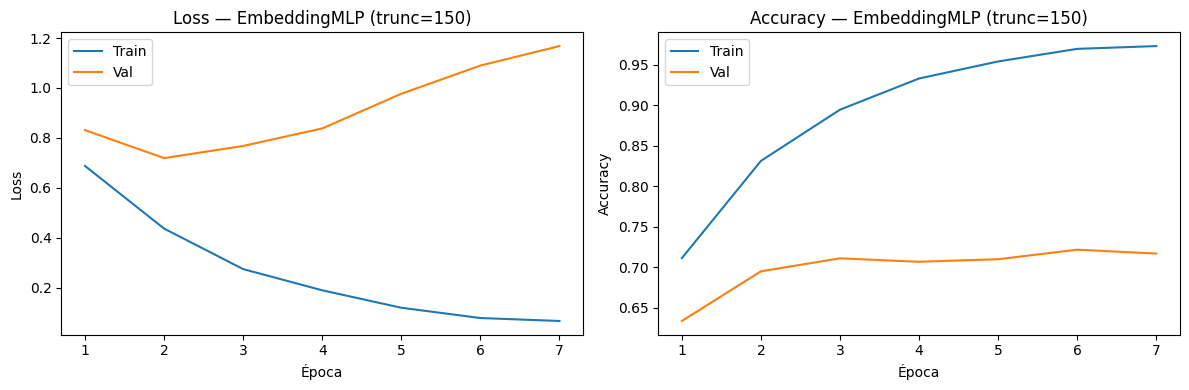

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
eps = range(1, len(history['train_loss']) + 1)
ax1.plot(eps, history['train_loss'], label='Train')
ax1.plot(eps, history['val_loss'],   label='Val')
ax1.set(xlabel='Época', ylabel='Loss',
        title=f'Loss — EmbeddingMLP (trunc={TRUNCATE_CHARS})')
ax1.legend()
ax2.plot(eps, history['train_acc'],  label='Train')
ax2.plot(eps, history['val_acc'],    label='Val')
ax2.set(xlabel='Época', ylabel='Accuracy',
        title=f'Accuracy — EmbeddingMLP (trunc={TRUNCATE_CHARS})')
ax2.legend()
plt.tight_layout(); plt.show()

Teste interno — Accuracy: 0.7077  Macro-F1: 0.7040

              precision    recall  f1-score   support

   anthropic     0.8511    0.8080    0.8290       375
      google     0.9167    0.9680    0.9416       375
       human     0.5414    0.7147    0.6161       375
        meta     0.6648    0.6187    0.6409       375
      openai     0.5771    0.4293    0.4924       375

    accuracy                         0.7077      1875
   macro avg     0.7102    0.7077    0.7040      1875
weighted avg     0.7102    0.7077    0.7040      1875



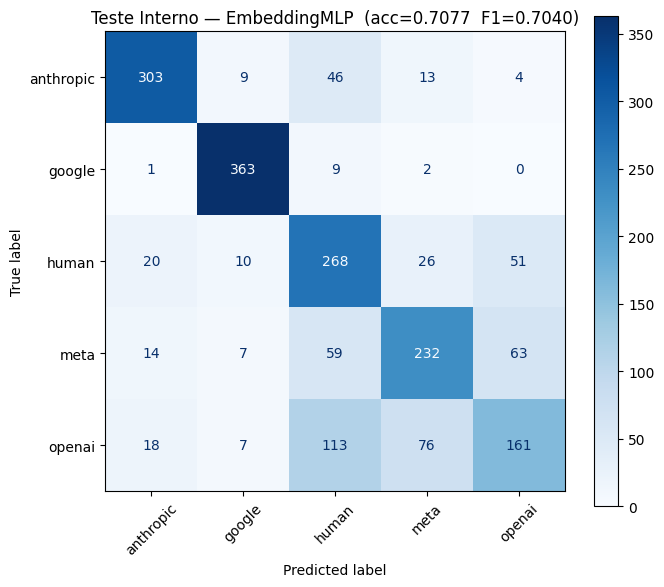

In [8]:
preds_int, targets_int = get_preds(model, seq_test_loader)

lbls    = [IDX_TO_CLASS[i] for i in range(N_CLASSES)]
acc_int = sum(p == t for p, t in zip(preds_int, targets_int)) / len(targets_int)
f1_int  = sk_f1(targets_int, preds_int, average='macro', zero_division=0)
print(f'Teste interno — Accuracy: {acc_int:.4f}  Macro-F1: {f1_int:.4f}\n')
print(classification_report(targets_int, preds_int, target_names=lbls, digits=4))

cm = confusion_matrix(targets_int, preds_int)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=lbls).plot(
    ax=ax, xticks_rotation=45, cmap='Blues', values_format='d')
ax.set_title(f'Teste Interno — EmbeddingMLP  (acc={acc_int:.4f}  F1={f1_int:.4f})')
plt.tight_layout(); plt.show()

## 7. Teste no Dataset Externo (`dataset-exemplos.csv`)

O mesmo `TRUNCATE_CHARS` é aplicado ao dataset externo para consistência.

In [9]:
CSV_PATH = 'dataset-exemplos.csv'
df_ext = pd.read_csv(CSV_PATH, sep=';')
df_ext.columns = df_ext.columns.str.strip()
df_ext['Label'] = df_ext['Label'].str.lower().str.strip()
df_ext['Text']  = df_ext['Text'].astype(str).apply(clean_text)

# Aplicar a mesma truncagem ao dataset externo
if TRUNCATE_CHARS is not None:
    df_ext['Text'] = df_ext['Text'].str[:TRUNCATE_CHARS]

df_ext = df_ext[df_ext['Label'].isin(CLASS_TO_IDX)].copy()
df_ext['label_id'] = df_ext['Label'].map(CLASS_TO_IDX)

X_ext = df_ext['Text'].tolist()
y_ext = df_ext['label_id'].tolist()

print(f'Registos externos: {len(df_ext)}')
print(df_ext['Label'].value_counts().to_string())

Registos externos: 125
Label
human        52
anthropic    23
meta         17
openai       17
google       16


Dataset Externo — Accuracy: 0.3680  Macro-F1: 0.2170

              precision    recall  f1-score   support

   anthropic     0.2000    0.1739    0.1860        23
      google     0.2000    0.0625    0.0952        16
       human     0.4318    0.7308    0.5429        52
        meta     0.3333    0.1176    0.1739        17
      openai     0.1667    0.0588    0.0870        17

    accuracy                         0.3680       125
   macro avg     0.2664    0.2287    0.2170       125
weighted avg     0.3100    0.3680    0.3077       125



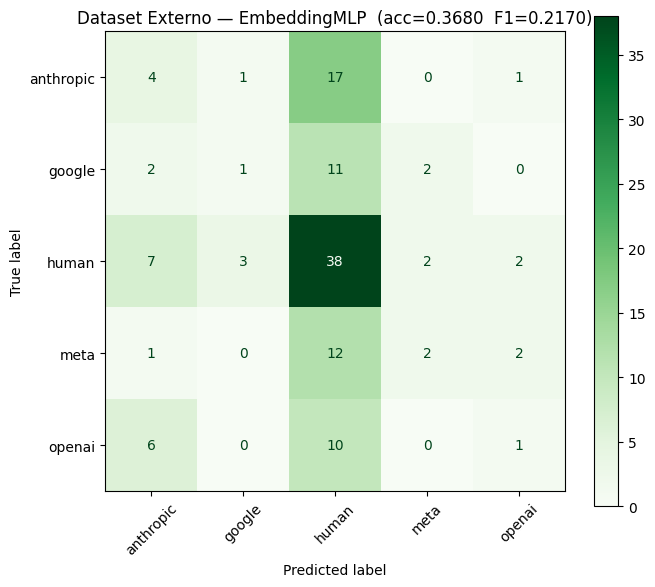

In [10]:
ext_loader = DataLoader(
    SequenceDataset(X_ext, y_ext, vocab_rnn, MAX_LEN), batch_size=BATCH_SIZE)

preds_ext, targets_ext = get_preds(model, ext_loader)

acc_ext = sum(p == t for p, t in zip(preds_ext, targets_ext)) / len(targets_ext)
f1_ext  = sk_f1(targets_ext, preds_ext, average='macro', zero_division=0)
print(f'Dataset Externo — Accuracy: {acc_ext:.4f}  Macro-F1: {f1_ext:.4f}\n')
print(classification_report(targets_ext, preds_ext, target_names=lbls, digits=4))

cm_ext = confusion_matrix(targets_ext, preds_ext)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_ext, display_labels=lbls).plot(
    ax=ax, xticks_rotation=45, cmap='Greens', values_format='d')
ax.set_title(f'Dataset Externo — EmbeddingMLP  (acc={acc_ext:.4f}  F1={f1_ext:.4f})')
plt.tight_layout(); plt.show()

TRUNCATE_CHARS = 150
       Dataset  Accuracy  Macro-F1
Interno (test)  0.707733  0.703993
       Externo  0.368000  0.217002


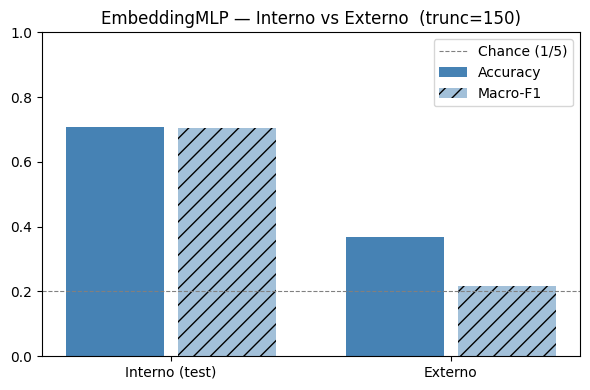

In [11]:
# ── Comparação interno vs externo ─────────────────────────────────────────────
df_compare = pd.DataFrame({
    'Dataset':  ['Interno (test)', 'Externo'],
    'Accuracy': [acc_int,          acc_ext],
    'Macro-F1': [f1_int,           f1_ext],
})
print(f'TRUNCATE_CHARS = {TRUNCATE_CHARS}')
print(df_compare.to_string(index=False))

x = [0, 1]
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([i - 0.2 for i in x], df_compare['Accuracy'], 0.35,
       label='Accuracy', color='steelblue')
ax.bar([i + 0.2 for i in x], df_compare['Macro-F1'], 0.35,
       label='Macro-F1', color='steelblue', alpha=0.5, hatch='//')
ax.set_xticks(x)
ax.set_xticklabels(df_compare['Dataset'])
ax.set_ylim(0, 1)
ax.axhline(1/N_CLASSES, color='grey', linestyle='--', lw=0.8,
           label=f'Chance (1/{N_CLASSES})')
ax.set_title(f'EmbeddingMLP — Interno vs Externo  (trunc={TRUNCATE_CHARS})')
ax.legend()
plt.tight_layout()
plt.show()